# Cosine similarity

In [1]:
from sentence_transformers import SentenceTransformer, util

In [2]:
# 1. Load a pre-trained "Semantic" model
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Experiment 1: Similarity between Bus, Car and Apple

In [3]:
# 2. Define our words
words = ["Bus", "Car", "Apple"]

# 3. Calculate the Vectors (Embeddings)
vectors = model.encode(words)

# 4. Compare "Bus" (index 0) to "Car" (index 1)
sim_bus_car_e1 = util.cos_sim(vectors[0], vectors[1])

# 5. Compare "Bus" (index 0) to "Apple" (index 2)
sim_bus_apple = util.cos_sim(vectors[0], vectors[2])

# 6. Compare "Car" (index 1) to "Apple" (index 2)
sim_car_apple = util.cos_sim(vectors[1], vectors[2])

print('Results of Experiment 1:')
print(f"Similarity Bus-Car: {sim_bus_car_e1.item():.4f}")
print(f"Similarity Bus-Apple: {sim_bus_apple.item():.4f}")
print(f"Similarity Car-Apple: {sim_car_apple.item():.4f}")

Results of Experiment 1:
Similarity Bus-Car: 0.4957
Similarity Bus-Apple: 0.2100
Similarity Car-Apple: 0.4098


## Experiment 2: Similarity between Bus, Car and Banana

In [4]:
# 2. Define our words
words = ["Bus", "Car", "Banana"]

# 3. Calculate the Vectors (Embeddings)
vectors = model.encode(words)

# 4. Compare "Bus" (index 0) to "Car" (index 1)
sim_bus_car_e2 = util.cos_sim(vectors[0], vectors[1])

# 5. Compare "Bus" (index 0) to "Banana" (index 2)
sim_bus_banana = util.cos_sim(vectors[0], vectors[2])

# 6. Compare "Car" (index 1) to "Banana" (index 2)
sim_car_banana = util.cos_sim(vectors[1], vectors[2])

print('Results of Experiment 2:')
print(f"Similarity Bus-Car: {sim_bus_car_e2.item():.4f}")
print(f"Similarity Bus-Banana: {sim_bus_banana.item():.4f}")
print(f"Similarity Car-Banana: {sim_car_banana.item():.4f}")

Results of Experiment 2:
Similarity Bus-Car: 0.4957
Similarity Bus-Banana: 0.3135
Similarity Car-Banana: 0.3899


## Experiment 3: Similarity betweeen Bus, Car & Tuesday

In [5]:
# 2. Define our words
words = ["Bus", "Car", "Tuesday"]

# 3. Calculate the Vectors (Embeddings)
vectors = model.encode(words)

# 4. Compare "Bus" (index 0) to "Car" (index 1)
sim_bus_car_e3 = util.cos_sim(vectors[0], vectors[1])

# 5. Compare "Bus" (index 0) to "Tuesday" (index 2)
sim_bus_tuesday = util.cos_sim(vectors[0], vectors[2])

# 6. Compare "Car" (index 1) to "Tuesday" (index 2)
sim_car_tuesday = util.cos_sim(vectors[1], vectors[2])

print('Results of Experiment 3:')
print(f"Similarity Bus-Car: {sim_bus_car_e3.item():.4f}")
print(f"Similarity Bus-Tuesday: {sim_bus_tuesday.item():.4f}")
print(f"Similarity Car-Tuesday: {sim_car_tuesday.item():.4f}")

Results of Experiment 3:
Similarity Bus-Car: 0.4957
Similarity Bus-Tuesday: 0.2040
Similarity Car-Tuesday: 0.2238


## Experiment 5: Queen - Lady + Men = ?

In [7]:
# Check what will be result of the (Queen - Lady + Man) can it be King? 
# 1. Define our words
words = ["Queen", "Lady", "Man", "King"]

# 2. Calculate the Vectors (Embeddings)
vectors = model.encode(words)

# Find the resultant vector
resultant_vector = (vectors[0] - vectors[1]) + vectors[2]
print('The vector embeddings are ', model.resultant_vector)

# 4. Compare Result of equation and the work "King"
sim_bus_car_e3 = util.cos_sim(vectors[0], vectors[1])

The vector embeddings are  [[ 0.03548702 -0.06560463 -0.00993493 ... -0.05388926 -0.03124185
  -0.08696105]
 [-0.07436639 -0.05408122  0.01849028 ... -0.03604683  0.02410908
  -0.0652834 ]
 [-0.10967563  0.04374185 -0.0263192  ... -0.06859671 -0.01288429
   0.00773392]
 [-0.05959933  0.05051238 -0.06951012 ... -0.03039852 -0.00108666
  -0.01592242]]


In [ ]:
# Define words to compare against
words_to_check = ["King", "Queen", "Lady", "Man", "Prince", "Princess"]

# Encode the words
word_vectors = model.encode(words_to_check)

# Calculate similarity between result_vector and each word
similarities = util.cos_sim(result_vector, word_vectors)

# Find the most similar word
most_similar_idx = similarities.argmax()
most_similar_word = words_to_check[most_similar_idx]
most_similar_score = similarities[0][most_similar_idx].item()

print(f"Result vector is most similar to: '{most_similar_word}' with similarity score: {most_similar_score:.4f}")
print(f"\nAll similarities:")
for word, score in zip(words_to_check, similarities[0]):
    print(f"  {word}: {score.item():.4f}")

## Comparing the results

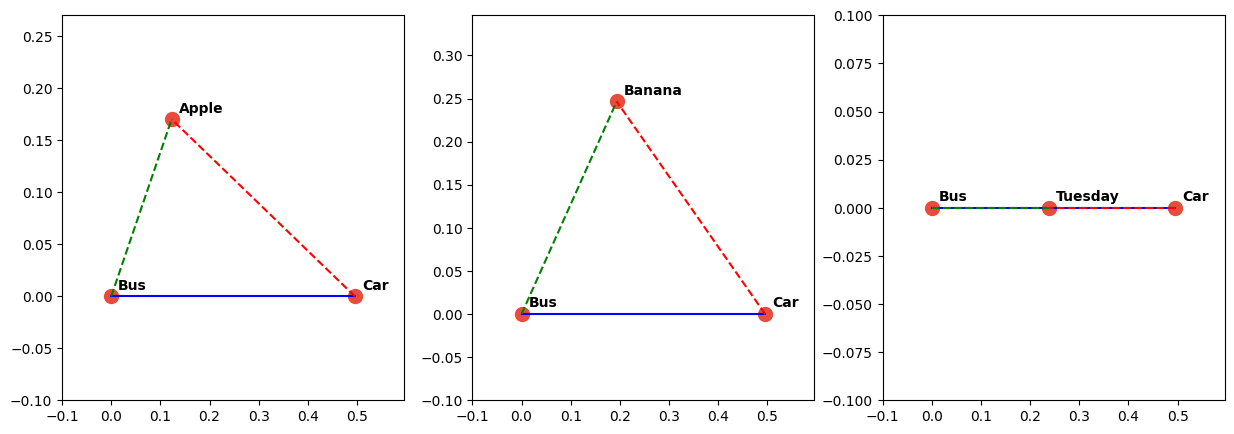

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# --- SEMANTIC MAP (GEOMETRIC TRIANGLES) ---
# This calculates 2D coordinates based on similarity (distance)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
experiments = [
    ("Exp 1", "Apple", sim_bus_car_e1.numpy()[0][0], sim_bus_apple.numpy()[0][0], sim_car_apple.numpy()[0][0]),
    ("Exp 2", "Banana", sim_bus_car_e2.numpy()[0][0], sim_bus_banana.numpy()[0][0], sim_car_banana.numpy()[0][0]),
    ("Exp 3", "Tuesday", sim_bus_car_e3.numpy()[0][0], sim_bus_tuesday.numpy()[0][0], sim_car_tuesday.numpy()[0][0])
]

for i, (name, target, bc, bt, ct) in enumerate(experiments):
    # Using the Law of Cosines to find coordinates (x, y)
    # so that distances between points match the similarity scores
    x_val = (bt**2 + bc**2 - ct**2) / (2 * bc)
    y_val = np.sqrt(max(0, bt**2 - x_val**2))

    # Plot points
    axes[i].scatter([0, bc, x_val], [0, 0, y_val], color='#e74c3c', s=100)
    labels = ["Bus", "Car", target]
    for j, txt in enumerate(labels):
        axes[i].annotate(txt, ([0, bc, x_val][j], [0, 0, y_val][j]), xytext=(5,5), textcoords='offset points', fontweight='bold')

    # Draw lines between data points
    axes[i].plot([0, bc], [0, 0], 'b-')
    axes[i].plot([0, x_val], [0, y_val], 'g--')
    axes[i].plot([bc, x_val], [0, y_val], 'r--')

    # Add some padding to the x and y axes
    max_x = max([0, bc, x_val])
    max_y = max([0, y_val])
    axes[i].set_xlim(-0.1, max_x + 0.1)
    axes[i].set_ylim(-0.1, max_y + 0.1)